In [1]:
%load_ext autoreload
%autoreload 2

from trees.data import Data

data = Data()
data.generate(n=10000)

,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,outcome,treatment,ITE,id
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,0.002523,-0.001684,-0.008669,-0.007690,0.012437,0.002649,0.012918,0.001693,0.001131,-0.005640,1.437047,0.502100,0.806172,4999.50000
std,1.022027,0.992098,1.003031,0.992401,0.998175,1.001443,1.010710,1.001298,0.995909,0.991762,3.290630,0.500021,1.158088,2886.89568
min,-4.295391,-4.465604,-3.940008,-3.631539,-3.856375,-3.726141,-4.462969,-3.601085,-3.419906,-4.157734,-12.041417,0.000000,-4.157076,0.00000
25%,-0.685254,-0.670339,-0.684620,-0.673858,-0.661041,-0.671775,-0.661183,-0.684996,-0.677070,-0.680137,-0.768118,0.000000,0.030921,2499.75000
50%,0.007853,-0.017794,-0.014492,0.005256,0.012248,0.009466,0.017331,0.001488,0.003151,0.003104,1.399103,1.000000,0.786993,4999.50000
75%,0.686816,0.666640,0.664414,0.657044,0.690269,0.676462,0.698700,0.672743,0.672574,0.674684,3.573415,1.000000,1.559871,7499.25000
max,3.727833,3.942331,3.829782,4.479084,3.594374,3.926238,3.602832,3.712795,3.605591,3.852731,14.667230,1.000000,6.516317,9999.00000


In [2]:
data.generate_random_condition()

'feature_4 <= 2.907321825475895'

# CF with criterion = mse

In [3]:
%%time
from trees.causal_forest import CF

cf = CF(data)
cf.fit(criterion="mse", n_estimators=100)

CPU times: user 2min 42s, sys: 2.69 s, total: 2min 45s
Wall time: 1min 55s


## Parse forests

In [4]:
%%time
cf.parse_forest()

CPU times: user 18.6 s, sys: 27.6 s, total: 46.2 s
Wall time: 10.9 s


In [5]:
cf.get_topK(k=10, w=0.6)

Score mean: 0.56 ± 0.03
Estimated CATE mean: 4.5 ± 0.26
True CATE mean: 2.89 ± 0.36
Distance mean: 0.03 ± 0.01
Depth: 3.3


,condition,t_est,distance,depth,norm_cate,score,algorithm,execution_time,t
285,feature_0 > 0.024 AND feature_0 > 1.749 AND fe...,4.893,0.02,3,1.000000,0.608000,CF (mse),115.52,3.029
442,feature_0 > 0.377 AND feature_0 > 1.568 AND fe...,4.812,0.02,4,0.983446,0.598067,CF (mse),115.52,3.112
601,feature_0 > -0.4 AND feature_1 > 0.508 AND fea...,4.721,0.03,3,0.964848,0.590909,CF (mse),115.52,2.049
56,feature_0 > 0.111 AND feature_0 <= 1.967 AND f...,4.677,0.03,4,0.955855,0.585513,CF (mse),115.52,2.629
664,feature_0 > 0.27 AND feature_1 > 1.166 AND fea...,4.553,0.03,3,0.930513,0.570308,CF (mse),115.52,3.258
49,feature_0 > -0.163 AND feature_0 > 1.96,4.354,0.03,2,0.889843,0.545906,CF (mse),115.52,3.180
270,feature_0 > -0.959 AND feature_1 > -0.346 AND ...,4.256,0.04,3,0.869814,0.537888,CF (mse),115.52,3.156
245,feature_0 > -0.937 AND feature_0 > 1.61 AND fe...,4.307,0.02,3,0.880237,0.536142,CF (mse),115.52,2.891
77,feature_0 > 0.085 AND feature_0 <= 1.96 AND fe...,4.298,0.02,4,0.878398,0.535039,CF (mse),115.52,2.715
541,feature_0 > 0.123 AND feature_1 > 0.461 AND fe...,4.160,0.04,4,0.850194,0.526116,CF (mse),115.52,2.860


## Derive a single tree with SingleTreeCateInterpreter

CPU times: user 1.13 s, sys: 414 ms, total: 1.54 s
Wall time: 1.11 s


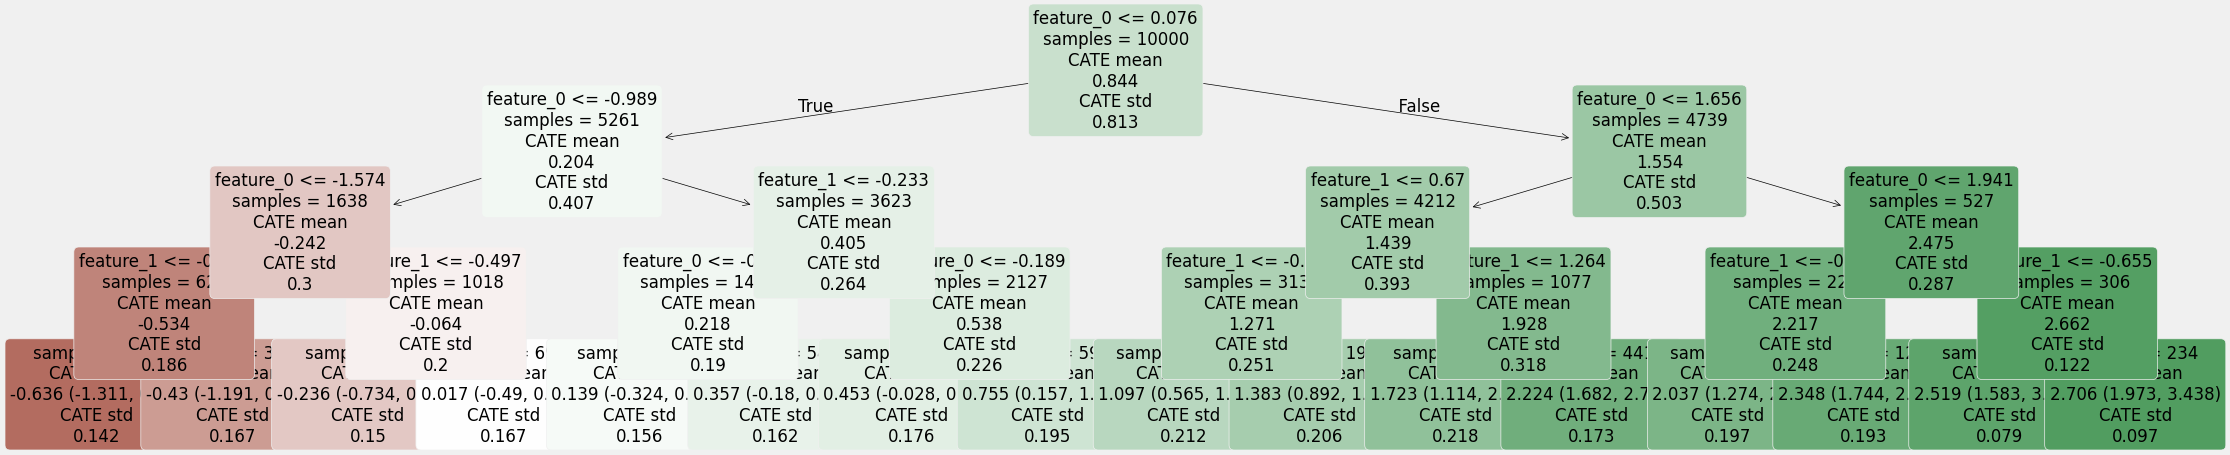

In [6]:
%%time
cf.single_tree_interpreter(print_tree=True)

In [7]:
cf.get_topK(k=10, w=0.6)

Score mean: 0.54 ± 0.05
Estimated CATE mean: 2.21 ± 0.44
True CATE mean: 2.57 ± 0.6
Distance mean: 0.12 ± 0.18
Depth: 3.0


,condition,t_est,distance,depth,norm_cate,score,algorithm,execution_time,t
29,feature_0 > 0.076 AND feature_0 > 1.656 AND fe...,2.706,0.02,4,1.000000,0.608000,CF (mse) SingleTreeInterpreter,115.52,3.327
27,feature_0 > 0.076 AND feature_0 > 1.656 AND fe...,2.662,0.03,3,0.983740,0.602244,CF (mse) SingleTreeInterpreter,115.52,3.162
23,feature_0 > 0.076 AND feature_0 > 1.656,2.475,0.05,2,0.914634,0.568780,CF (mse) SingleTreeInterpreter,115.52,2.933
28,feature_0 > 0.076 AND feature_0 > 1.656 AND fe...,2.519,0.01,4,0.930894,0.562537,CF (mse) SingleTreeInterpreter,115.52,2.622
15,feature_0 > 0.076,1.554,0.47,1,0.574279,0.532568,CF (mse) SingleTreeInterpreter,115.52,1.672
26,feature_0 > 0.076 AND feature_0 > 1.656 AND fe...,2.348,0.01,4,0.867701,0.524621,CF (mse) SingleTreeInterpreter,115.52,2.951
22,feature_0 > 0.076 AND feature_0 <= 1.656 AND f...,2.224,0.04,4,0.821877,0.509126,CF (mse) SingleTreeInterpreter,115.52,2.650
24,feature_0 > 0.076 AND feature_0 > 1.656 AND fe...,2.217,0.02,3,0.819290,0.499574,CF (mse) SingleTreeInterpreter,115.52,2.617
16,feature_0 > 0.076 AND feature_0 <= 1.656,1.439,0.42,2,0.531781,0.487069,CF (mse) SingleTreeInterpreter,115.52,1.515
20,feature_0 > 0.076 AND feature_0 <= 1.656 AND f...,1.928,0.11,3,0.712491,0.471494,CF (mse) SingleTreeInterpreter,115.52,2.251


# CT with criterion = het

In [8]:
%%time
from trees.causal_forest import CF

cf = CF(data)
cf.fit(criterion="het", n_estimators=100)

CPU times: user 2min 20s, sys: 1.81 s, total: 2min 21s
Wall time: 1min 42s


## Parse forests

In [9]:
%%time
cf.parse_forest()

CPU times: user 19.2 s, sys: 28.8 s, total: 48 s
Wall time: 10.9 s


In [10]:
cf.get_topK(k=10, w=0.6)


Score mean: 0.57 ± 0.02
Estimated CATE mean: 4.17 ± 0.18
True CATE mean: 2.96 ± 0.09
Distance mean: 0.03 ± 0.01
Depth: 2.8


,condition,t_est,distance,depth,norm_cate,score,algorithm,execution_time,t
418,feature_0 > 0.102 AND feature_0 > 1.597 AND fe...,4.495,0.03,3,1.000000,0.612000,CF (het),102.72,2.882
306,feature_0 > 0.024 AND feature_0 > 1.749 AND fe...,4.443,0.02,3,0.988432,0.601059,CF (het),102.72,3.079
54,feature_0 > -0.163 AND feature_0 > 1.825,4.188,0.04,2,0.931702,0.575021,CF (het),102.72,3.067
335,feature_0 > 0.1 AND feature_0 > 1.724 AND feat...,4.238,0.02,3,0.942825,0.573695,CF (het),102.72,3.022
451,feature_0 > -0.102 AND feature_0 > 1.596 AND f...,4.193,0.02,4,0.932814,0.567689,CF (het),102.72,2.895
459,feature_0 > -0.509 AND feature_0 > 1.601 AND f...,4.148,0.03,3,0.922803,0.565682,CF (het),102.72,2.897
304,feature_0 > 0.024 AND feature_0 > 1.749,4.031,0.04,2,0.896774,0.554065,CF (het),102.72,3.021
262,feature_0 > -0.371 AND feature_1 <= 0.962 AND ...,4.016,0.03,3,0.893437,0.548062,CF (het),102.72,2.829
704,feature_0 > 0.101 AND feature_0 > 1.768,3.956,0.04,2,0.880089,0.544053,CF (het),102.72,3.024
359,feature_0 > -0.011 AND feature_0 > 1.664 AND f...,3.994,0.02,3,0.888543,0.541126,CF (het),102.72,2.931


## Derive a single tree with SingleTreeCateInterpreter

CPU times: user 1.1 s, sys: 407 ms, total: 1.51 s
Wall time: 1.15 s


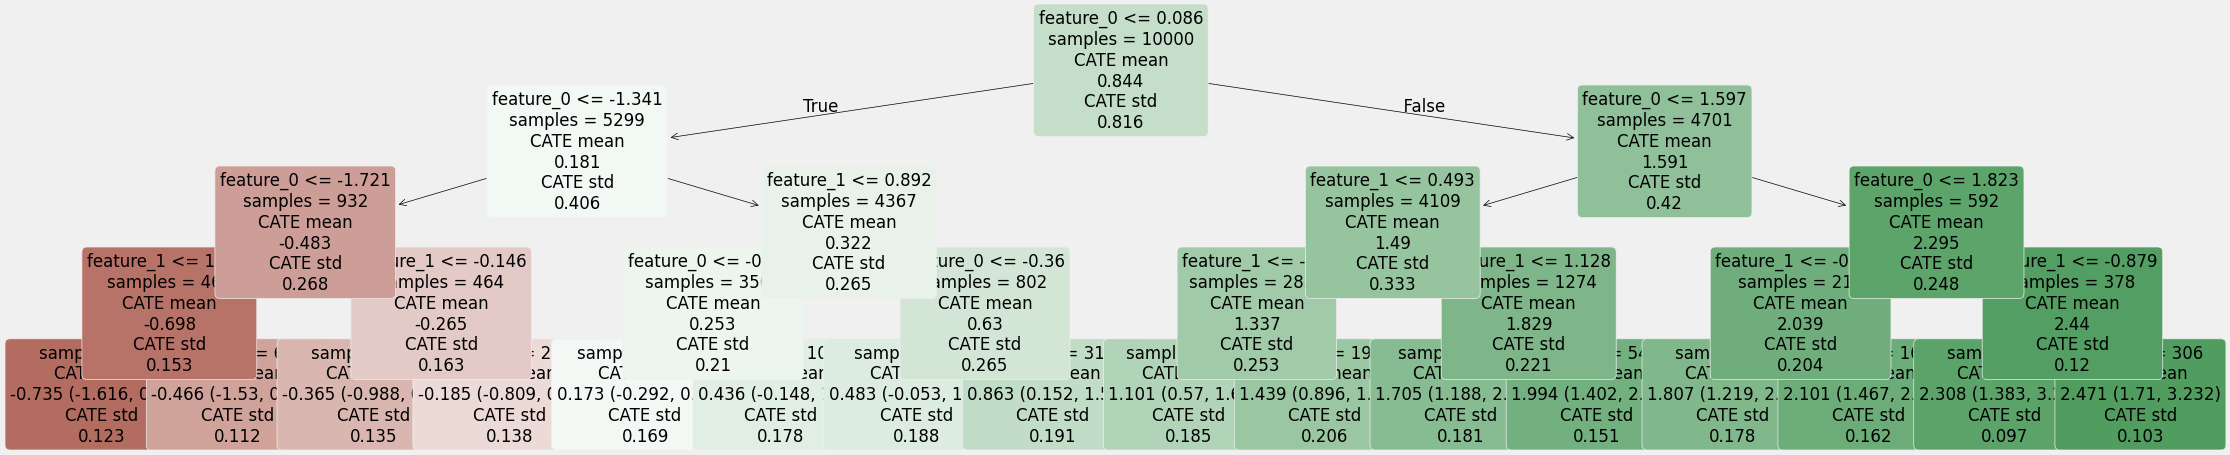

In [11]:
%%time
cf.single_tree_interpreter(print_tree=True)

In [12]:
cf.get_topK(k=10, w=0.6)

Score mean: 0.55 ± 0.04
Estimated CATE mean: 2.06 ± 0.34
True CATE mean: 2.48 ± 0.56
Distance mean: 0.12 ± 0.17
Depth: 3.0


,condition,t_est,distance,depth,norm_cate,score,algorithm,execution_time,t
29,feature_0 > 0.086 AND feature_0 > 1.597 AND fe...,2.471,0.03,4,1.000000,0.612000,CF (het) SingleTreeInterpreter,102.72,3.202
27,feature_0 > 0.086 AND feature_0 > 1.597 AND fe...,2.440,0.04,3,0.987454,0.608473,CF (het) SingleTreeInterpreter,102.72,3.066
23,feature_0 > 0.086 AND feature_0 > 1.597,2.295,0.06,2,0.928774,0.581264,CF (het) SingleTreeInterpreter,102.72,2.883
15,feature_0 > 0.086,1.591,0.47,1,0.643869,0.574321,CF (het) SingleTreeInterpreter,102.72,1.678
28,feature_0 > 0.086 AND feature_0 > 1.597 AND fe...,2.308,0.01,4,0.934035,0.564421,CF (het) SingleTreeInterpreter,102.72,2.486
16,feature_0 > 0.086 AND feature_0 <= 1.597,1.490,0.41,2,0.602995,0.525797,CF (het) SingleTreeInterpreter,102.72,1.505
26,feature_0 > 0.086 AND feature_0 > 1.597 AND fe...,2.101,0.02,4,0.850263,0.518158,CF (het) SingleTreeInterpreter,102.72,2.719
22,feature_0 > 0.086 AND feature_0 <= 1.597 AND f...,1.994,0.05,4,0.806961,0.504176,CF (het) SingleTreeInterpreter,102.72,2.538
24,feature_0 > 0.086 AND feature_0 > 1.597 AND fe...,2.039,0.02,3,0.825172,0.503103,CF (het) SingleTreeInterpreter,102.72,2.556
20,feature_0 > 0.086 AND feature_0 <= 1.597 AND f...,1.829,0.13,3,0.740186,0.496112,CF (het) SingleTreeInterpreter,102.72,2.145
